In [11]:
import os, sys
import pandas as pd
import torch
import importlib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    precision_recall_curve, 
    roc_curve,
)
import numpy as np
from tqdm import tqdm

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

sys.path.append(str(PROJECT_DIR))

import utils
import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import plotting_utils
import stat_utils

training_cache_dir = DATA_DIR / "training_data_cache_new"
tf_tg_input_cache_dir = training_cache_dir / "tf_tg_training_data_cache"

tf_dna_model_chkpt = CHKPT_DIR / "tfbind_train_3671604" / "epoch=06-val_auroc=0.9186-val_loss=0.2750.ckpt"
tf_tg_model_chkpt = CHKPT_DIR / "tf_tg_train_3675131" / "epoch=09-val_auroc=0.6889-val_loss=0.5970.ckpt"


### Function to load the trained TF-TG binding model

In [2]:

def load_tf_tg_binding_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path
    ) -> tf_to_tg_module.TFTGRegulationModel:
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    state = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )
    lit_model.load_state_dict(state["state_dict"], strict=True)

    # 3) Get the trained base model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 4) Create the TF→TG model using the trained TF→DNA model, and load its checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

### Function to load a cached dataset (train/val/test)

In [3]:
def load_training_cache_dataset(training_cache_dir: Path, tf_tg_input_cache_dir: Path, split_type: str = "test", subset_size: int = None) -> DataLoader:
    assert split_type in ["train", "val", "test"], \
        "split_type must be one of 'train', 'val', or 'test'"
    
    # Load the compact split inputs
    tftg_inputs_test = torch.load(
        tf_tg_input_cache_dir / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        training_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        training_cache_dir / "tf_masks.pt",
        weights_only=True,
    )
    atac_peak_tensor = torch.load(
        tf_tg_input_cache_dir / "atac_peak_tensor.pt",
        weights_only=True,
    )

    # Load the metadata
    with open(tf_tg_input_cache_dir / "metadata.json", "r") as f:
        metadata = json.load(f)

    # Load the manifest and verify tensor shapes and dtypes match expectations
    with open(tf_tg_input_cache_dir / "manifest.json") as f:
        manifest = json.load(f)
    
    assert tuple(manifest["atac_peak_tensor_shape"]) == tuple(atac_peak_tensor.shape)
    assert manifest["atac_peak_tensor_dtype"] == str(atac_peak_tensor.dtype)

    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs_test,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )
    
    if subset_size is not None:
        dataset = Subset(dataset, list(range(subset_size)))

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )
    
    return loader, metadata, manifest


### Run model predictions on the trained dataset

In [12]:
print(f"Loading TF→TG model")
tf_tg_model = load_tf_tg_binding_model(tf_dna_model_chkpt, tf_tg_model_chkpt)

dataset_split_type = "test"
subset_size = 5000

print(f"Loading cached dataset with subset size: {subset_size}")
data_loader, metadata, manifest = load_training_cache_dataset(
    training_cache_dir, 
    tf_tg_input_cache_dir, 
    split_type=dataset_split_type, 
    subset_size=subset_size
    )

print("Moving model to device")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_tg_model.model
model = model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
score_threshold = 0.5
pooling_mode = "lse"
pooling_temperature = 1.0

model.eval()

total_loss = 0.0
n_edges = 0

all_scores = []
all_labels = []

print(f"Evaluating on {dataset_split_type} set")
for batch in tqdm(data_loader, desc="Evaluating"):
    batch = tf_to_tg_module.move_batch_to_device(batch, device)

    labels = batch["label"]
    cell_mask = batch["cell_mask"]
    E, C = cell_mask.shape

    edge_logits, _ = model.forward(
        tf_embedding=batch["tf_embedding"],
        tf_mask=batch["tf_mask"],
        peak_sequences=batch["peak_sequences"],
        peak_accessibility=batch["peak_accessibility"],
        peak_distance=batch["peak_distance"],
        tf_expression=batch["tf_expression"],
        tg_expression=batch["tg_expression"],
        peak_mask=batch.get("peak_mask", None),
        cell_mask=cell_mask,
        pooling_mode=pooling_mode,
        pooling_temperature=pooling_temperature,
    )

    loss = criterion(edge_logits, labels)

    total_loss += loss.item() * E
    n_edges += E

    scores = torch.sigmoid(edge_logits)

    all_scores.append(scores.detach().cpu().numpy().ravel())
    all_labels.append(labels.detach().cpu().numpy().ravel())

all_scores_flat = np.concatenate(all_scores)
all_labels_flat = np.concatenate(all_labels)

Loading TF→TG model
Loading cached dataset with subset size: 5000


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Moving model to device
Evaluating on test set


Evaluating: 100%|███████████████████████████████████████████████████████████████████████████| 79/79 [00:32<00:00,  2.44it/s]


### Evaluate the predictions

In [83]:
importlib.reload(stat_utils)
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

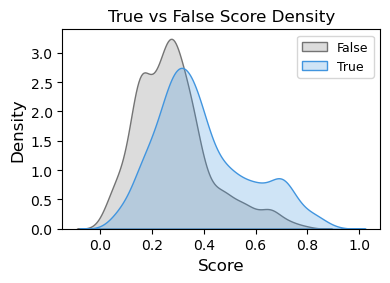

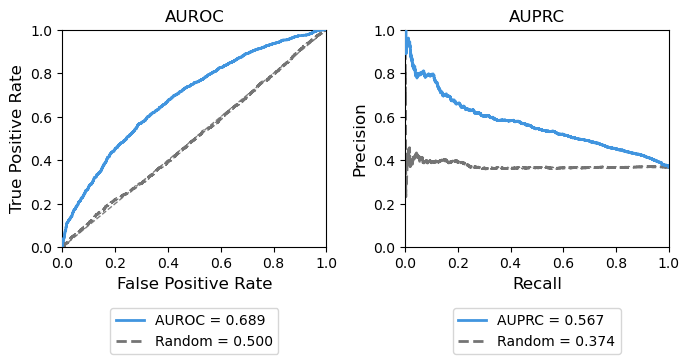

In [13]:
histogram_fig = plotting_utils.plot_score_histograms(
    labels=all_labels_flat,
    scores=all_scores_flat,
    n_bins=25,
    y_log=False,
    panel_kind="kde",
    density=False,
)
histogram_fig.show()

auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
    labels=all_labels_flat,
    scores=all_scores_flat,
)
auroc_auprc_fig.show()

In [14]:
metrics = stat_utils.compute_binary_classification_metrics(
    labels=all_labels_flat,
    scores=all_scores_flat,
    score_threshold=score_threshold,
    random_state=42,
)

mean_loss = total_loss / max(n_edges, 1)

metrics["loss"] = mean_loss
metrics["score_min"] = float(all_scores_flat.min())
metrics["score_max"] = float(all_scores_flat.max())
metrics["score_mean"] = float(all_scores_flat.mean())
metrics["score_std"] = float(all_scores_flat.std())
metrics["n_pred_pos"] = int((all_scores_flat >= score_threshold).sum())
metrics["n_pred_neg"] = int((all_scores_flat < score_threshold).sum())

metric_df = pd.DataFrame([metrics])

print("Final Test Metrics:")
print(metric_df.T)

Final Test Metrics:
                           0
auroc               0.689008
auprc               0.567119
rand_auroc          0.521653
rand_auprc          0.380708
accuracy            0.669600
precision           0.627049
n_edges          5000.000000
n_pos            1838.000000
n_neg            3162.000000
score_threshold     0.500000
loss                0.610729
score_min           0.005237
score_max           0.904415
score_mean          0.320466
score_std           0.167101
n_pred_pos        732.000000
n_pred_neg       4268.000000
